# 전처리 & 머신러닝 통합 개인과제

## Part 2. 구매 고객 특성 분석 및 시각화

### 실무 시나리오

전자상거래 기업의 CRM팀은 모든 고객에게 동일한 프로모션을 제공하면서 마케팅 비용이 증가하고 있습니다.  
이에 데이터 분석팀은 Part 1에서 정제한 고객 데이터를 활용하여 **구매율과 구매금액이 높은 고객군을 찾고, 고객의 구매 행동을 설명할 수 있는 주요 변수를 확인**하려고 합니다.

수강생은 데이터 분석 담당자로서 다음 업무를 수행합니다.

1. 고객군별 구매 특성을 비교합니다.
2. 구매 행동의 분포와 변수 간 관계를 시각화합니다.
3. 분석 결과를 바탕으로 Part 3 구매예측 모델에 사용할 Feature 후보를 정리합니다.

> 문제 1~3은 필수 문제입니다.  
> 문제 4는 추가 분석을 위한 심화 문제이며 선택적으로 수행합니다.  
> 차트 종류와 표현 방식은 정해진 하나의 답만 있는 것이 아닙니다. 분석 목적에 적절하고 제목·축·범례가 명확하면 인정합니다.

## 과제 목표

- 전처리된 데이터의 주요 구매 현황을 확인할 수 있습니다.
- 두 개 이상의 기준으로 고객 데이터를 집계하고 집단별 구매 차이를 설명할 수 있습니다.
- 분석 목적에 적합한 차트를 선택하고 기본 시각 요소를 설정할 수 있습니다.
- EDA 결과를 근거로 머신러닝 Feature 후보를 제안할 수 있습니다.

## 사용 환경 및 데이터

- Python 3.X
- pandas, numpy
- `전자상거래_고객구매_전처리완료.csv`

# 문제 1. 주요 고객군의 구매 특성 비교

## 업무 상황

CRM팀은 프로모션 대상을 정하기 위해 어떤 고객군의 구매율과 구매금액이 높은지 확인하려고 합니다.  
전체 평균만 확인하면 집단별 차이를 알기 어렵기 때문에, 고객 특성을 기준으로 구매 실적을 비교해야 합니다.

## 필수 요구사항

1. 전처리 완료 데이터를 불러오고 데이터 크기와 주요 컬럼을 확인하세요.
2. 전체 고객 수, 구매 고객 수, 구매율과 주요 수치형 변수의 기초 통계량을 확인하세요.
3. 회원등급, 지역, 연령대, 선호 카테고리 중 적절한 기준을 선택하여 고객군별 구매 특성을 집계하세요.
4. **두 개 이상의 기준을 함께 사용한 그룹 집계**를 1개 이상 수행하세요.
5. 집계 결과를 바탕으로 구매율 또는 평균 구매금액이 높은 고객군을 간단히 설명하세요.

## 힌트

- 고객 수, 구매 고객 수, 구매율, 평균 구매금액, 평균 방문횟수 등을 집계 지표로 활용할 수 있습니다.
- 구매율이 높더라도 고객 수가 매우 적다면 해석에 주의해야 합니다.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

DATA_PATH = Path("전자상거래_고객구매_전처리완료.csv")
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# TODO: 전처리 완료 데이터를 불러와 df에 저장하세요.
df = pd.read_csv(DATA_PATH)

# TODO: 데이터 크기, 주요 컬럼과 앞부분을 확인하세요.
print("데이터 크기:", df.shape)
print("컬럼:", df.columns.tolist())
display(df.head())

데이터 크기: (1500, 17)
컬럼: ['CustomerID', 'Gender', 'Age', 'Region', 'MembershipLevel', 'VisitCount', 'AveragePurchaseAmount', 'TotalPurchaseAmount', 'SatisfactionScore', 'LastPurchaseDate', 'CouponUsed', 'PreferredCategory', 'SignupDate', 'Email', 'PurchaseStatus', 'AgeGroup', 'PurchaseGrade']


,CustomerID,Gender,Age,Region,MembershipLevel,VisitCount,AveragePurchaseAmount,TotalPurchaseAmount,SatisfactionScore,LastPurchaseDate,CouponUsed,PreferredCategory,SignupDate,Email,PurchaseStatus,AgeGroup,PurchaseGrade
0,CUST101486,Female,40.0,Seoul,Silver,5.0,75000.0,139800.0,3.7,2026-02-07,N,Beauty,2022-12-03,customer1486@example.com,0,40대,Low
1,CUST100113,Male,39.0,Gyeonggi,Basic,7.0,74400.0,159200.0,4.8,2026-04-22,N,Home,2021-07-16,customer113@example.com,1,30대,Low
2,CUST100168,Male,39.0,Gwangju,Silver,12.0,185800.0,1055800.0,4.5,2026-06-06,N,Beauty,2022-02-15,customer168@example.com,1,30대,High
3,CUST101212,Male,44.0,Daegu,VIP,7.0,153900.0,413200.0,4.5,2026-05-07,N,Home,2021-10-27,customer1212@example.com,1,40대,Medium
4,CUST100312,Male,37.0,Gyeonggi,Basic,14.0,123700.0,576000.0,4.0,2026-04-16,N,Home,2025-11-08,customer312@example.com,1,30대,High


In [2]:
# TODO: 전체 고객 수, 구매 고객 수, 구매율과 주요 수치형 변수의 기초 통계량을 확인하세요.
print("전체 고객 수:", len(df), "명")
print("구매 고객 수:", df["PurchaseStatus"].sum(), "명")
print("구매율:", round(df["PurchaseStatus"].mean() * 100, 1))

num_cols = ["Age", "VisitCount", "AveragePurchaseAmount",
            "TotalPurchaseAmount", "SatisfactionScore"]
df[num_cols].describe()

전체 고객 수: 1500 명
구매 고객 수: 733 명
구매율: 48.9


,Age,VisitCount,AveragePurchaseAmount,TotalPurchaseAmount,SatisfactionScore
count,1500.000000,1500.000000,1500.000000,1.500000e+03,1500.000000
mean,39.335333,9.050000,120133.850000,3.888998e+05,3.662600
std,10.575527,2.943004,51800.021117,2.604137e+05,0.746194
min,18.000000,1.000000,5000.000000,5.000000e+03,1.700000
25%,32.000000,7.000000,83700.000000,1.864250e+05,3.200000
50%,39.000000,9.000000,117500.000000,3.360500e+05,3.700000
75%,47.000000,11.000000,150450.000000,5.360250e+05,4.200000
max,69.500000,17.000000,250575.000000,1.060425e+06,5.000000


In [3]:
# TODO: 고객 특성 한 가지를 기준으로 구매 특성을 집계하세요.
total_group = df.groupby("MembershipLevel").agg(
    고객수=("CustomerID", "count"),
    구매고객수=("PurchaseStatus", "sum"),
    구매율=("PurchaseStatus", "mean"),
    평균구매금액=("TotalPurchaseAmount", "mean"),
    평균방문횟수=("VisitCount", "mean")
).round(2)

total_group

,고객수,구매고객수,구매율,평균구매금액,평균방문횟수
MembershipLevel,,,,,
Basic,697,297,0.43,322199.93,9.06
Gold,276,167,0.61,467788.04,9.00
Silver,419,181,0.43,390673.15,9.10
VIP,108,88,0.81,610878.01,8.90


In [4]:
# TODO: 두 개 이상의 기준을 함께 사용하여 그룹 집계를 수행하세요.
교차_구매율 = df.pivot_table(
    index="MembershipLevel",
    columns="AgeGroup",
    values="PurchaseStatus",
    aggfunc="mean"
).round(3)

print("[회원등급 × 연령대 구매율]")
display(교차_구매율)

교차_고객수 = df.pivot_table(
    index="MembershipLevel",
    columns="AgeGroup",
    values="CustomerID",
    aggfunc="count"
)

print("[회원등급 × 연령대 고객 수]")
display(교차_고객수)

[회원등급 × 연령대 구매율]


AgeGroup,20대 이하,30대,40대,50대,60대 이상
MembershipLevel,,,,,
Basic,0.390,0.407,0.421,0.560,0.333
Gold,0.579,0.652,0.580,0.606,0.538
Silver,0.417,0.479,0.389,0.450,0.333
VIP,0.917,0.769,0.758,1.000,0.750


[회원등급 × 연령대 고객 수]


AgeGroup,20대 이하,30대,40대,50대,60대 이상
MembershipLevel,,,,,
Basic,118,246,221,91,21
Gold,57,92,81,33,13
Silver,72,144,131,60,12
VIP,24,39,33,8,4


### 문제 1 결과 정리

- 전체 구매 현황:전체 고객 수: 1500 명, 구매 고객 수: 733 명, 구매율: 48.9%
- 구매율이 높은 고객군: VIP 81%(108명) > Gold 61%(276명) > Silver 43%(419명) = Basic 43%(697명)
- 평균 구매금액이 높은 고객군: VIP의 평균 구매금액이 610878원으로 가장 높다. VIP의 총 인원은 108명인데 20대 이하는 24명, 30대 39명, 40대 33명, 50대 8명, 60대 이상은 4명이다.
- 고객 수를 함께 고려했을 때 주의할 점:
등급이 VIP인 50대는 구매율 100%지만 8명으로 같은 연령대에 비해 구매한 고객 인원도 적다. 확실한 구매의사가 있었던 VIP 50대 고객일수도 있다.

# 문제 2. 구매 행동의 분포와 관계 시각화

## 업무 상황

고객군별 평균만으로는 실제 데이터가 어느 구간에 집중되어 있는지, 일부 극단값이 평균에 영향을 주는지 알기 어렵습니다.  
CRM팀이 결과를 쉽게 이해할 수 있도록 구매 행동의 분포, 고객군 간 차이, 변수 간 관계를 시각화해야 합니다.

## 필수 요구사항

1. 구매금액, 방문횟수, 만족도 등 주요 수치형 변수 중 하나 이상의 분포를 시각화하세요.
2. 회원등급, 구매 여부 등 고객 집단별 차이를 비교할 수 있는 차트를 작성하세요.
3. 두 수치형 변수의 관계를 확인할 수 있는 차트를 작성하세요.
4. 모든 차트에 분석 내용을 이해할 수 있는 제목과 축 이름을 표시하고, 필요한 경우 범례를 추가하세요.
5. 차트에서 확인한 주요 패턴을 간단히 설명하세요.

## 힌트

- 분포 확인에는 히스토그램이나 박스플롯을 사용할 수 있습니다.
- 집단 비교에는 막대그래프나 그룹별 박스플롯을 사용할 수 있습니다.
- 수치형 변수 관계에는 산점도를 사용할 수 있습니다.

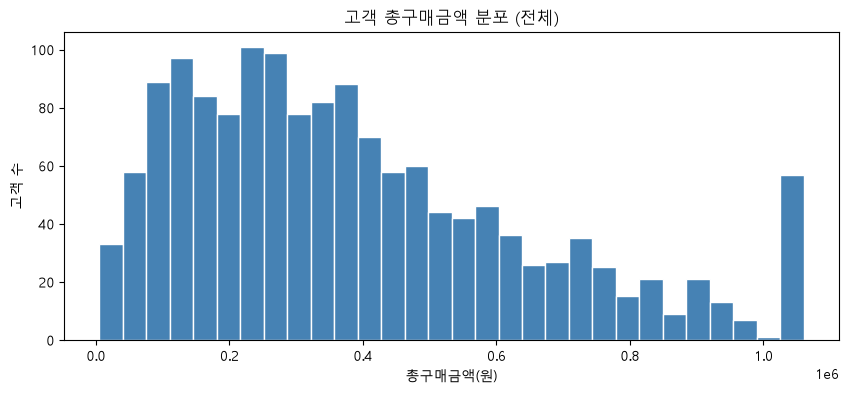

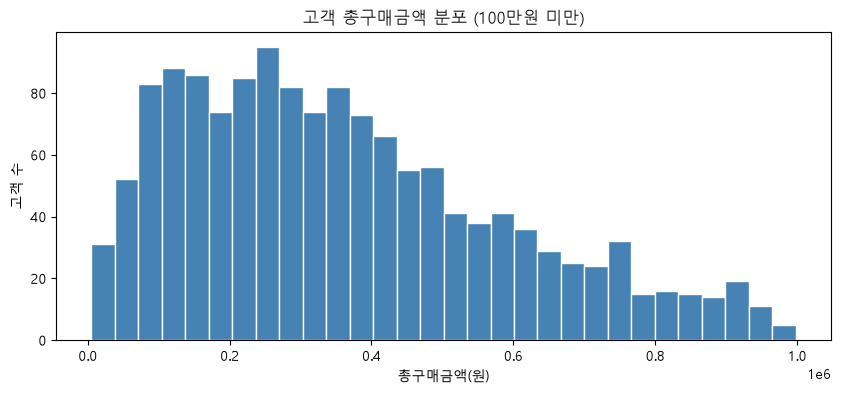

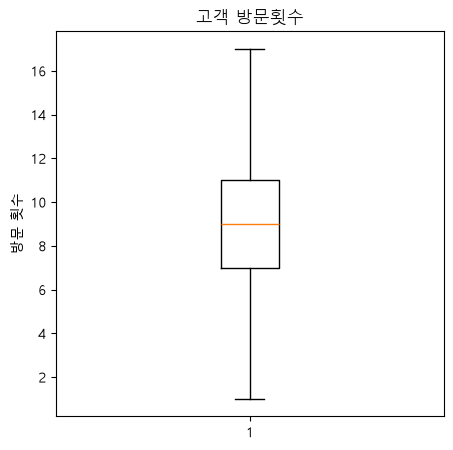

In [5]:
# TODO: 주요 수치형 변수의 분포를 시각화하세요.
plt.figure(figsize=(10, 4))
plt.hist(df["TotalPurchaseAmount"], bins=30, color="steelblue", edgecolor="white")
plt.xlabel("총구매금액(원)")
plt.ylabel("고객 수")
plt.title("고객 총구매금액 분포 (전체)")
plt.show()

small= df[df["TotalPurchaseAmount"] < 1000000]
plt.figure(figsize=(10, 4))
plt.hist(small["TotalPurchaseAmount"], bins=30, color="steelblue", edgecolor="white")
plt.xlabel("총구매금액(원)")
plt.ylabel("고객 수")
plt.title("고객 총구매금액 분포 (100만원 미만)")
plt.show()

plt.figure(figsize=(5, 5))
plt.boxplot(df["VisitCount"])
plt.ylabel("방문 횟수")
plt.title("고객 방문횟수")
plt.show()



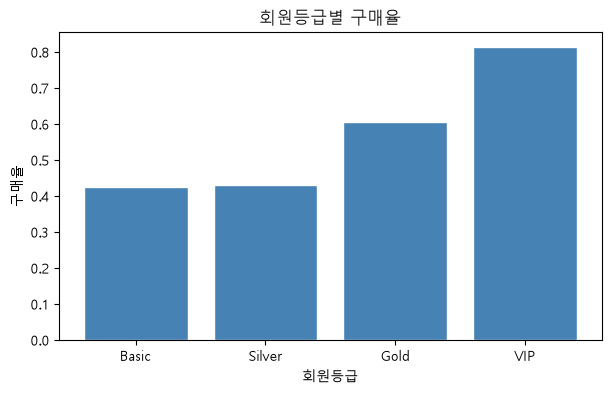

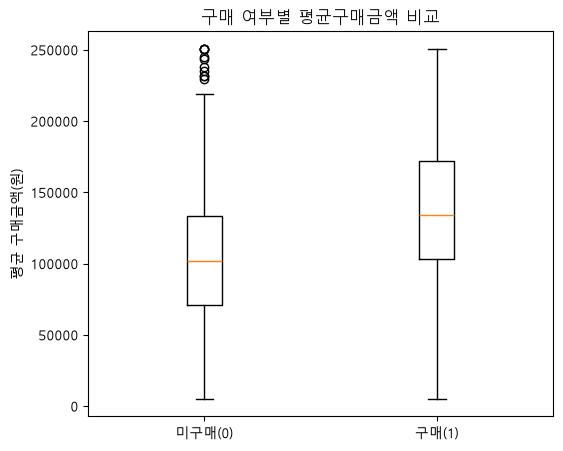

In [6]:
# TODO: 고객 집단별 구매 차이를 비교하는 차트를 작성하세요.
grade_pur = df.groupby("MembershipLevel")["PurchaseStatus"].mean()
grade_pur = grade_pur.reindex(["Basic", "Silver", "Gold", "VIP"])

plt.figure(figsize=(7, 4))
plt.bar(grade_pur.index, grade_pur.values, color="steelblue", edgecolor="white")
plt.xlabel("회원등급")
plt.ylabel("구매율")
plt.title("회원등급별 구매율")
plt.show()

no_pur = df[df["PurchaseStatus"] == 0]["AveragePurchaseAmount"]
pur = df[df["PurchaseStatus"] == 1]["AveragePurchaseAmount"]

plt.figure(figsize=(6, 5))
plt.boxplot([no_pur, pur], tick_labels=["미구매(0)", "구매(1)"])
plt.ylabel("평균 구매금액(원)")
plt.title("구매 여부별 평균구매금액 비교")
plt.show()


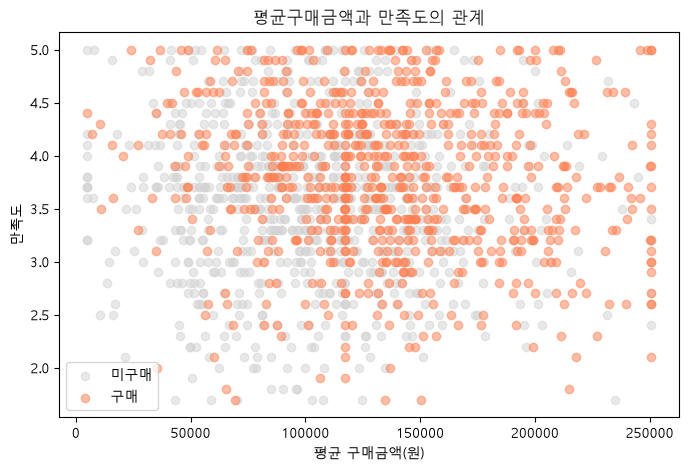

상관계수: -0.018


In [7]:
# TODO: 두 수치형 변수의 관계를 확인하는 차트를 작성하세요.
no_pur = df[df["PurchaseStatus"] == 0]
pur = df[df["PurchaseStatus"] == 1]

plt.figure(figsize=(8, 5))
plt.scatter(no_pur["AveragePurchaseAmount"], no_pur["SatisfactionScore"],
            alpha=0.5, color="lightgray", label="미구매")
plt.scatter(pur["AveragePurchaseAmount"], pur["SatisfactionScore"],
            alpha=0.5, color="coral", label="구매")
plt.xlabel("평균 구매금액(원)")
plt.ylabel("만족도")
plt.title("평균구매금액과 만족도의 관계")
plt.legend()
plt.show()

print("상관계수:", round(df["AveragePurchaseAmount"].corr(df["SatisfactionScore"]), 3))

### 문제 2 결과 정리

- 주요 변수의 분포 특징: 총 구매금액 분포도를 보면, 10~40만원대에 몰려있어서 왼쪽으로 살짝 치우쳐져있다.
방문횟수 박스플롯은 상자가 7회~11회, 가운데 선이 9회에 있다. 17회이상은 전처리로 바꿨기 때문에 수염은 1회부터 17회까지 보인다.
- 고객 집단별 차이: 회원 등급이 높을 수록 구매율이 오른다.  Basic 약 43% / Silver 약 43% / Gold 약 61% / VIP 약 81%로 Gold와 VIP의 구매율 차이는 약 20%다. 
평균 구매금액도 등급 순서대로 오른다. Basic 322,199원 / Silver 390,673원 / Gold 467,788원 / VIP 610,878원
- 두 변수 사이에서 확인한 관계: 평균구매금액과 만족도의 상관계수가 -0.018이다. 산점도를 봤을 때 점들이 넓게 퍼져 있고 오른쪽으로 갈수록 올라가거나 내려가는 흐름이 보이지 않는다.
- 시각화 결과가 고객 분석에 주는 의미: 등급별로 프로모션을 진행한다. silver 이하과 Gold 이상으로 기준을 나눠서 진행한다. 50대, 60대 이상 VIP인 고객은 같은 연령이어도 다른 등급에 비해 고객 수가 적다. 고객군을 비교할때는 평균과 함께 중앙값, 고객 수를 함께 비교한다.

# 문제 3. 구매예측 모델링 Feature 후보 정리

## 업무 상황

Part 3에서는 고객의 구매 여부를 예측하는 머신러닝 모델을 개발합니다.  
모델에 모든 컬럼을 그대로 넣기보다, 이번 EDA에서 구매 행동과 관련성이 확인된 변수와 제외해야 할 변수를 구분해야 합니다.

## 필수 요구사항

1. 수치형 변수와 `PurchaseStatus`의 관계를 확인할 수 있는 표 또는 시각화를 작성하세요.
2. 문제 1과 문제 2의 분석 결과를 바탕으로 모델링에 사용할 Feature 후보를 정리하세요.
3. 고객 식별자처럼 일반적인 구매 패턴 학습에 적절하지 않은 컬럼을 제외 후보로 구분하세요.
4. 각 Feature 후보를 선정한 근거를 EDA 결과와 연결하여 간단히 설명하세요.

## 힌트

- 상관계수는 수치형 변수 사이의 선형 관계를 확인하는 참고 자료입니다.
- 상관계수가 낮더라도 범주형 변수나 비선형 관계를 가진 변수는 모델에 유용할 수 있습니다.
- 고객 ID와 같은 고유 식별자는 새로운 고객의 구매 패턴을 일반화하는 데 적절하지 않을 수 있습니다.

[PurchaseStatus와의 상관계수]
PurchaseStatus           1.000
TotalPurchaseAmount      0.380
AveragePurchaseAmount    0.324
VisitCount               0.244
SatisfactionScore        0.170
Age                      0.016
Name: PurchaseStatus, dtype: float64


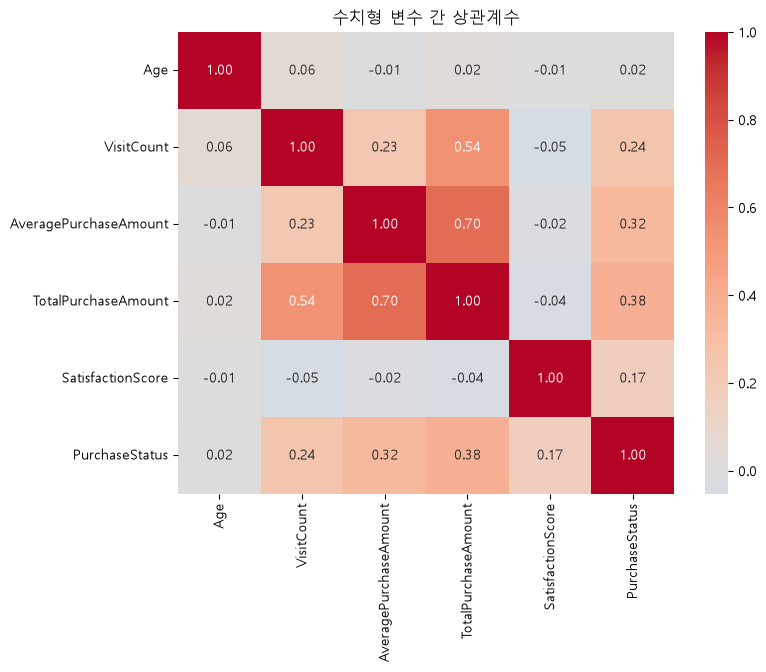

[구매 여부별 중앙값]


,Age,VisitCount,AveragePurchaseAmount,TotalPurchaseAmount,SatisfactionScore
PurchaseStatus,,,,,
0,39.0,8.0,101900.0,247700.0,3.6
1,39.0,10.0,133800.0,445200.0,3.8


In [8]:
# TODO: 수치형 변수와 PurchaseStatus의 관계를 확인하세요.
num_cols = ["Age", "VisitCount", "AveragePurchaseAmount",
            "TotalPurchaseAmount", "SatisfactionScore", "PurchaseStatus"]

print("[PurchaseStatus와의 상관계수]")
상관 = df[num_cols].corr()["PurchaseStatus"].sort_values(ascending=False)
print(상관.round(3))

# 히트맵
plt.figure(figsize=(8, 6))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("수치형 변수 간 상관계수")
plt.show()

print("[구매 여부별 중앙값]")
display(df.groupby("PurchaseStatus")[num_cols[:-1]].median().round(1))

In [ ]:
# TODO: EDA 결과를 바탕으로 Feature 후보와 제외 후보를 정리하세요.
feature_수치형 = ["AveragePurchaseAmount", "SatisfactionScore", "VisitCount", "Age"]
feature_범주형 = ["MembershipLevel", "PreferredCategory", "Region", "CouponUsed", "Gender"]
제외후보 = ["CustomerID", "Email", "SignupDate", "LastPurchaseDate",
            "TotalPurchaseAmount", "PurchaseGrade", "AgeGroup"]

print("[수치형 Feature]", feature_수치형)
print("[범주형 Feature]", feature_범주형)
print("[제외 후보]", 제외후보)

# 범주형 변수별 구매율 차이 확인
print("\n[범주형 변수의 구매율]")
for col in feature_범주형:
    print(f"\n{col}")
    display(df.groupby(col)["PurchaseStatus"].agg(["count", "mean"]).round(3))

[수치형 Feature] ['AveragePurchaseAmount', 'SatisfactionScore', 'VisitCount', 'Age']
[범주형 Feature] ['MembershipLevel', 'PreferredCategory', 'Region', 'CouponUsed', 'Gender']
[제외 후보] ['CustomerID', 'Email', 'SignupDate', 'LastPurchaseDate', 'TotalPurchaseAmount', 'PurchaseGrade', 'AgeGroup']

[범주형 변수의 구매율]

MembershipLevel


,count,mean
MembershipLevel,,
Basic,697,0.426
Gold,276,0.605
Silver,419,0.432
VIP,108,0.815



PreferredCategory


,count,mean
PreferredCategory,,
Beauty,239,0.473
Electronics,263,0.570
Fashion,374,0.468
Food,247,0.470
Home,210,0.476
Sports,167,0.473



Region


...


CouponUsed


,count,mean
CouponUsed,,
N,864,0.457
Y,636,0.531



Gender


,count,mean
Gender,,
Female,731,0.476
Male,696,0.500
Other,47,0.596
Unknown,26,0.346


: 

### 문제 3 결과 정리

#### 모델링 Feature 후보

- 수치형 Feature: AveragePurchaseAmount, SatisfactionScore, VisitCount, Age
- 범주형 Feature: MembershipLevel, PreferredCategory, Region, CouponUsed, Gender
- 선정 근거:
AveragePurchaseAmount는 상관계수 0.324로 제외 대상을 뺀 변수 중 가장 높다. 중앙값도 구매 133,800원, 미구매 101,900원이다. 
VisitCount는 0.244로 중앙값이 구매 10회, 미구매 8회로 확인된다. 구매한 고객이 미구매한 고객보다 방문횟수가 많다.
SatisfactionScore는 0.170이다. 중앙값이 구매 3.8점 대 미구매 3.6점이다. 점수 차이는 크지 않아도 방문횟수와 상관관계가 없어 겹치치 않는 유의미한 정보라 볼 수 있다.
Age는 0.016로 연령대별 구매율이 50대 55.2%, 60대 이상 42.0%로 확인된다.
MembershipLevel은 구매율이 Basic 42.6% / Silver 43.2% / Gold 60.5% / VIP 81.5%다. 가장 높은 등급인 VIP와 가장 낮은 등급인 Basic 등급의 차이가 38.9%로 변수가 크다.
PreferredCategory : Electronics만 57.0%로 나머지(약 46~47%)보다 10%p 높다.
CouponUsed : 쿠폰 사용 53.1%, 미사용 45.7%로 7.4%p 차이다.
Region : 대구 56.5%, 광주 43.0%로 13.5%p 차이. 그렇지만 count수가 108명, 149명이다.
Gende : Other 59.6%, Unknown 34.6%로 차이가 크지만 47명, 26명이다.
Female은 731명으로 47.6%, Male은 696명으로 50.0%이다.


#### 제외 후보

- 제외할 컬럼:CustomerID, Email, SignupDate, LastPurchaseDate, TotalPurchaseAmount, PurchaseGrade, AgeGroup
- 제외 이유:TotalPurchaseAmount가 상관계수가 가장 높지만 구매가 일어난 뒤에 확정되는 값이라 예측 시점에는 알 수 없다.
CustomerID와 Email은 고객마다 값이 다른 고유 식별값이다.
SignupDate와 LastPurchaseDate는 날짜형이라 모델에 그대로 넣을 수 없다.
PurchaseGrade는 TotalPurchaseAmount에서 비롯된 파생변수이다.
AgeGroup은 Age를 5개 구간으로 나눈 것이라 Age와 정보가 중복처리 된다.


# (심화)문제 4. 분석 결과의 심화 해석

## 업무 상황

CRM팀은 기본 분석 결과를 실제 마케팅과 구매예측 모델에 적용하기 전에,
고객군별 결과의 활용 가능성과 해석상의 주의점, 모델링 변수 구성의 위험 요소를 추가로 확인하려고 합니다.

## 요구사항

### 4-1. 고객군 활용 방안 제안

1. 문제 1의 집계 결과를 바탕으로 우선 관리할 고객군을 한 개 이상 선정하세요.
2. 해당 고객군을 선정한 근거를 구매율, 평균 구매금액, 고객 수 등의 지표와 연결하여 작성하세요.
3. 선정한 고객군에 적용할 수 있는 마케팅 활용 방안을 한 가지 이상 제안하세요.

### 4-2. 시각화 결과 해석 시 주의점

1. 문제 2의 분포 또는 집단 비교 차트에서 확인되는 치우침, 극단값, 집단별 차이 중 하나 이상을 설명하세요.
2. 해당 결과를 해석할 때 주의해야 할 점을 작성하세요.
3. 필요하다면 기존 분석을 보완하는 추가 차트를 한 개 작성하세요.

### 4-3. 모델링 Feature 위험 요소 검토

1. 서로 비슷한 정보를 제공하여 중복 가능성이 있는 변수를 한 쌍 이상 제시하세요.
2. 예측 시점에 사용할 수 없거나 구매 결과를 직접 반영하여 데이터 누수 가능성이 있는 변수를 검토하세요.
3. 최종 Feature 구성을 수치형 변수와 범주형 변수로 나누어 정리하세요.



## 심화 문제 결과 작성

### 4-1. 고객군 활용 방안

- 우선 관리할 고객군:
- 선정 근거:
- 제안할 마케팅 활용 방안:

### 4-2. 시각화 해석 시 주의점

- 확인한 분포 또는 집단 차이:
- 해석 시 주의할 점:
- 추가로 작성한 차트와 확인 결과:

### 4-3. Feature 위험 요소

- 중복 정보 가능성이 있는 변수:
- 데이터 누수 가능성이 있는 변수:
- 최종 수치형 Feature:
- 최종 범주형 Feature:




# 제출 결과물

## 필수 제출 결과물

| 결과물 | 제출 내용 |
|---|---|
| 전체 구매 현황 | 전체 고객 수, 구매 고객 수, 구매율, 주요 기초 통계량 |
| 고객군별 집계표 | 단일 기준 및 두 개 이상 기준의 그룹 집계 |
| 고객군 해석 | 구매율 또는 평균 구매금액이 높은 고객군 설명 |
| 주요 시각화 | 분포, 고객 집단 비교, 두 수치형 변수 관계 차트 |
| Feature 후보 | 모델링에 사용할 Feature와 제외 후보 및 선정 근거 |

## 심화 제출 결과물

| 결과물 | 제출 내용 |
|---|---|
| 고객군 활용 방안 | 우선 관리 고객군과 마케팅 제안 |
| 시각화 해석 주의점 | 치우침·극단값·집단 차이 해석과 주의사항 |
| Feature 위험 검토 | 중복 정보와 데이터 누수 가능성 검토 |
| 최종 Feature 구성 | 수치형·범주형 Feature 구분 |

# 제출 전 체크리스트

## 필수 체크리스트

- [ ] Part 1 전처리 완료 데이터를 사용했습니다.
- [ ] 전체 구매 현황과 주요 기초 통계량을 확인했습니다.
- [ ] 두 개 이상의 기준을 사용한 그룹 집계를 수행했습니다.
- [ ] 구매 특성이 두드러진 고객군을 설명했습니다.
- [ ] 분포, 집단 비교, 변수 관계를 확인할 수 있는 시각화를 작성했습니다.
- [ ] 차트에 제목, 축 이름과 필요한 범례를 표시했습니다.
- [ ] EDA 결과를 바탕으로 Feature 후보와 제외 후보를 정리했습니다.

## 심화 체크리스트

- [ ] 우선 관리할 고객군과 마케팅 활용 방안을 제안했습니다.
- [ ] 분포 또는 집단 차이를 해석할 때의 주의점을 설명했습니다.
- [ ] 필요에 따라 추가 차트를 작성했습니다.
- [ ] 중복 정보 가능성이 있는 변수를 검토했습니다.
- [ ] 데이터 누수 가능성이 있는 변수를 검토했습니다.
- [ ] 최종 Feature를 수치형과 범주형으로 구분했습니다.
